In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("C:\\Users\\ROYAL INFOTECH\\Downloads\\Online Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(536641, 8)

In [13]:
df["CustomerID"].isnull().sum()

np.int64(135037)

In [14]:
df = df.dropna(subset=["CustomerID"])

In [15]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [16]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
#total cancellation invoiceno
df[df["InvoiceNo"].astype(str).str.startswith("C")].shape

(8872, 8)

In [18]:
#Removing all cancel invoiceno
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [19]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].shape

(0, 8)

In [20]:
#checking negative quantity
(df["Quantity"] < 0).sum()

np.int64(0)

In [21]:
#checking negative unit price
(df["UnitPrice"] <= 0).sum()

np.int64(40)

In [22]:
#Removing negative unit price
df = df[df["UnitPrice"] > 0]

In [23]:
(df["UnitPrice"] <= 0).sum()

np.int64(0)

In [24]:
df.shape

(392692, 8)

In [26]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [27]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [28]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [29]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [30]:
reference_date

Timestamp('2011-12-10 12:50:00')

In [31]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [32]:
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}, inplace=True)

In [33]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [35]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [36]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


RFM SCORE

In [37]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)

In [38]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


In [39]:
rfm["RFM_Score"].describe()

count    4338.000000
mean        9.000000
std         3.589625
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_Score, dtype: float64

In [40]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
3     184
4     363
5     338
6     427
7     381
8     380
9     324
10    349
11    349
12    314
13    287
14    295
15    347
Name: count, dtype: int64

In [41]:
def segment_customer(score):
    if score >= 14:
        return "Champions"
    elif score >= 12:
        return "Loyal Customers"
    elif score >= 9:
        return "Potential Loyalists"
    elif score >= 6:
        return "At Risk"
    else:
        return "Lost Customers"

In [42]:
rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)

In [52]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,7,At Risk
12347.0,2,7,4310.00,5,5,5,15,Champions
12348.0,75,4,1797.24,2,4,4,10,Potential Loyalists
12349.0,19,1,1757.55,4,1,4,9,Potential Loyalists
12350.0,310,1,334.40,1,1,2,4,Lost Customers


In [43]:
rfm["Segment"].value_counts()

Segment
At Risk                1188
Potential Loyalists    1022
Lost Customers          885
Champions               642
Loyal Customers         601
Name: count, dtype: int64

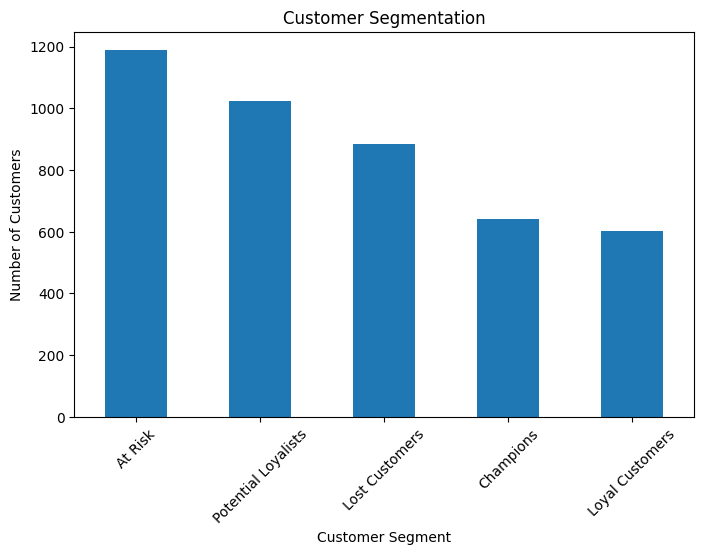

In [44]:
#Customer Segmentaion Chart
segment_counts = rfm["Segment"].value_counts()

segment_counts.plot(kind="bar", figsize=(8,5))

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [47]:
#Segment-wise revenue
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

segment_revenue

Segment
Champions              5208438.500
Loyal Customers        1585142.490
Potential Loyalists    1202274.721
At Risk                 689295.663
Lost Customers          202057.520
Name: Monetary, dtype: float64

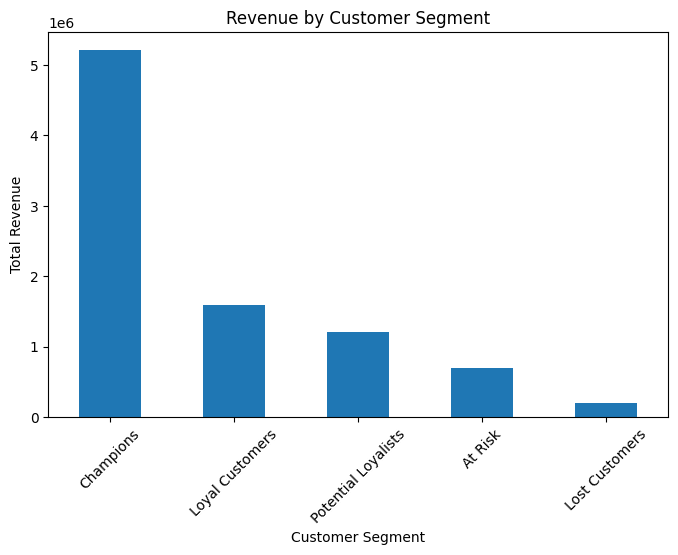

In [48]:
#Segment-wise Revenue Chart
segment_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [49]:
#Segment-wise average Monetary value
segment_avg = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

segment_avg

Segment
Champions              8112.832555
Loyal Customers        2637.508303
Potential Loyalists    1176.394052
At Risk                 580.215205
Lost Customers          228.313582
Name: Monetary, dtype: float64

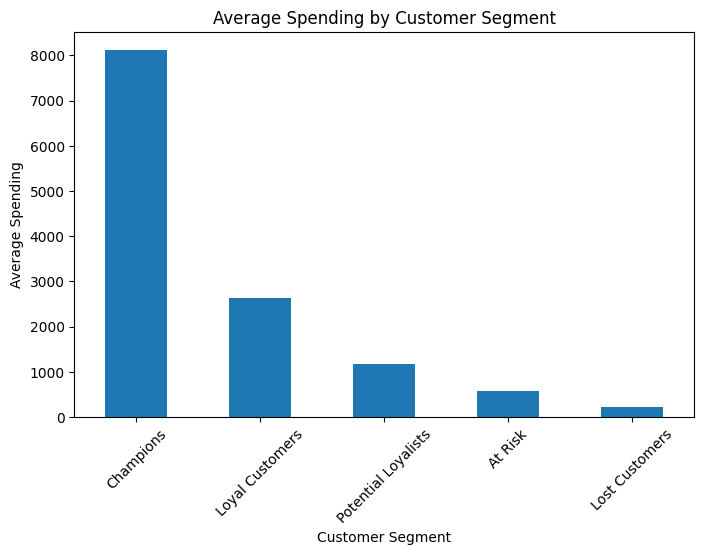

In [50]:
segment_avg.plot(kind="bar", figsize=(8,5))

plt.title("Average Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.show()

In [53]:
rfm.to_csv("Customer_RFM_Segmentation.csv")